In [24]:
from z3 import *
import numpy as np
import random
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.autolayout"] = True # to for tight_layout()
import arviz as az
# our library
from z3 import *
import numpy as np
import re
import arviz as az
import matplotlib.pyplot as plt
import os, sys
from importlib import reload

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(project_root)

import src.sat_metropolis.sat as sat
import src.sat_metropolis.smt as smt
import src.sat_metropolis.mcmc as mcmc
import src.sat_metropolis.utils as utils
import src.sat_metropolis.models as models
# from sat_metropolis import smt, mcmc, sat, utils

reload(sat)
reload(smt)
reload(mcmc)
reload(utils)
reload(models)

<module 'src.sat_metropolis.models' from '/Users/efh/Desktop/6. semester/Bachelor/sat-metropolis-businessnisser/src/sat_metropolis/models.py'>

In [25]:
# Taken from (Simson Garfinkel, John M. Abowd, Christian Martindale. Understanding Database Reconstruction Attacks on Public Data. Communications of the ACM, March 2019, Vol. 62 No. 3, Pages 46-53. DOI: 10.1145/3287287)

# Assumption, all bit-vectors are of the same size
num_bits = 8
num_vars = 5*2 # (age, gender)
var_list = [BitVec(f'x{i}',num_bits) for i in range(num_vars)] # 0-4 age vars, 5-9 sex vars
x = var_list
g = Goal()
sat.add_bool_vars_to_goal(g, var_list)
g.add(sat.addition_does_not_overflow([x[0], x[1], x[2], x[3], x[4]]))
g.add(sat.addition_does_not_overflow([x[5], x[6], x[7], x[8], x[9]]))
for i in range(5):
    g.add(sat.multi_does_not_overflow([x[i],x[i+5]])) # this is in case of multiplication

# these are binary (obviously only for the purpose of the example)
# FEMALE = 0
# MALE = 1
for i in range(5,10):
    g.add(ULE(0,x[i]))
    g.add(ULE(x[i],1))


# establish an order to set the median
g.add(ULE(0,x[0]))
g.add(ULE(x[0],x[1]))
g.add(ULE(x[1],x[2]))
g.add(ULE(x[2],x[3]))
g.add(ULE(x[3],x[4]))
g.add(ULE(x[4],125))

g.add(x[2] == 30) # median

g.add(x[0] + x[1] + x[2] + x[3] + x[4] == 38*5) # average age

g.add(x[5] + x[6] + x[7] + x[8] + x[9] == 3) # only 3 males

g.add(x[0]*x[5] + x[1]*x[6] + x[2]*x[7] + x[3]*x[8] + x[4]*x[9] == 44*3) # average age of males

# NOTE: we might need to set an overflow constraint for the last sum.


In [8]:
# trace = sat.get_conditional_incremental_samples_sat_pyunigen_problem_cached(
#     z3_problem=g,
#     num_vars=num_vars,
#     num_bits=num_bits,
#     D=3,
#     num_samples=1,
#     num_iterations=1000,
#     sanity_check_problem=True,
#     print_z3_model=False
# )

variables_number: {1: k!3221, 2: x00, 3: k!3222, 4: x01, 5: k!3223, 6: x02, 7: k!3224, 8: x03, 9: k!3225, 10: x04, 11: k!3226, 12: x05, 13: k!3227, 14: x06, 15: k!3228, 16: x07, 17: k!3229, 18: x10, 19: k!3230, 20: x11, 21: k!3231, 22: x12, 23: k!3232, 24: x13, 25: k!3233, 26: x14, 27: k!3234, 28: x15, 29: k!3235, 30: x16, 31: k!3236, 32: x17, 33: k!3237, 34: x20, 35: k!3238, 36: x21, 37: k!3239, 38: x22, 39: k!3240, 40: x23, 41: k!3241, 42: x24, 43: k!3242, 44: x25, 45: k!3243, 46: x26, 47: k!3244, 48: x27, 49: k!3245, 50: x30, 51: k!3246, 52: x31, 53: k!3247, 54: x32, 55: k!3248, 56: x33, 57: k!3249, 58: x34, 59: k!3250, 60: x35, 61: k!3251, 62: x36, 63: k!3252, 64: x37, 65: k!3253, 66: x40, 67: k!3254, 68: x41, 69: k!3255, 70: x42, 71: k!3256, 72: x43, 73: k!3257, 74: x44, 75: k!3258, 76: x45, 77: k!3259, 78: x46, 79: k!3260, 80: x47, 81: k!3261, 82: x50, 83: k!3262, 84: x51, 85: k!3263, 86: x52, 87: k!3264, 88: x53, 89: k!3265, 90: x54, 91: k!3266, 92: x55, 93: k!3267, 94: x56, 95:

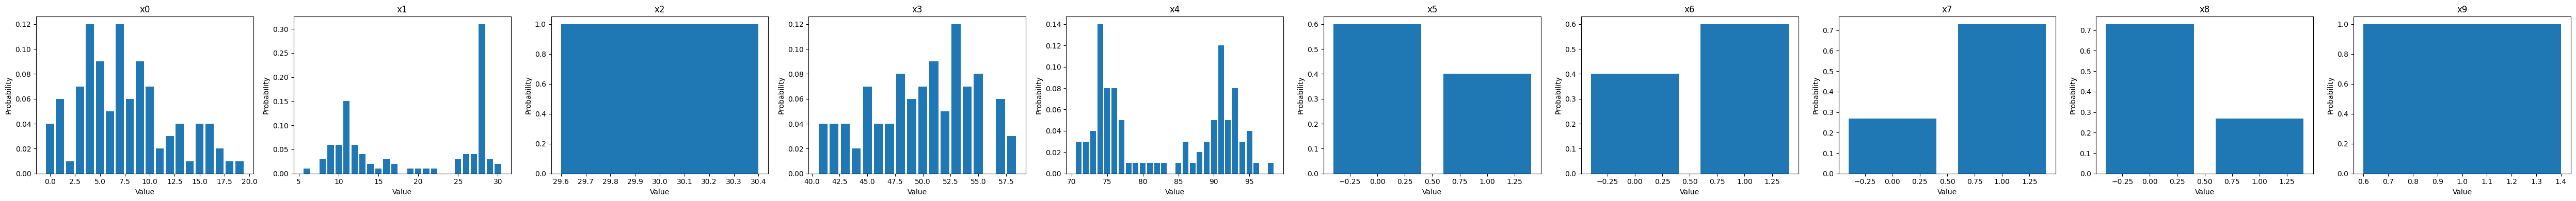

In [26]:
trace=mcmc.sample_mh_trace_from_z3_model(
    backend='inc_pyunigen_new',
    z3_problem=g,
    D=3,
    num_vars=num_vars,
    num_bits=num_bits,
    parallel_samples=5,
    num_samples=100,
    num_iterations=100,
    print_z3_model=False
)


In [10]:
# trace = mcmc.sample_mh_trace_from_z3_model(backend='unigen',
#                                            z3_problem=g,
#                                            num_vars=num_vars,
#                                            num_bits=num_bits,
#                                            timeout_sampler=3600,
#                                            num_samples=5000,
#                                            num_chains=10)

In [19]:
trace

Inference data with groups:
	> posterior

In [20]:
from collections import Counter
import matplotlib.pyplot as plt
import math

def plot_distributions(samples):
    keys = list(samples[0].keys())
    n = len(keys)

    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for ax, key in zip(axes, keys):
        vals = [d[key] for d in samples]
        c = Counter(vals)

        xs = sorted(c.keys())
        total = sum(c.values())
        ys = [c[x] / total for x in xs]

        ax.bar(xs, ys)
        ax.set_title(key)
        ax.set_xlabel("Value")
        ax.set_ylabel("Probability")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

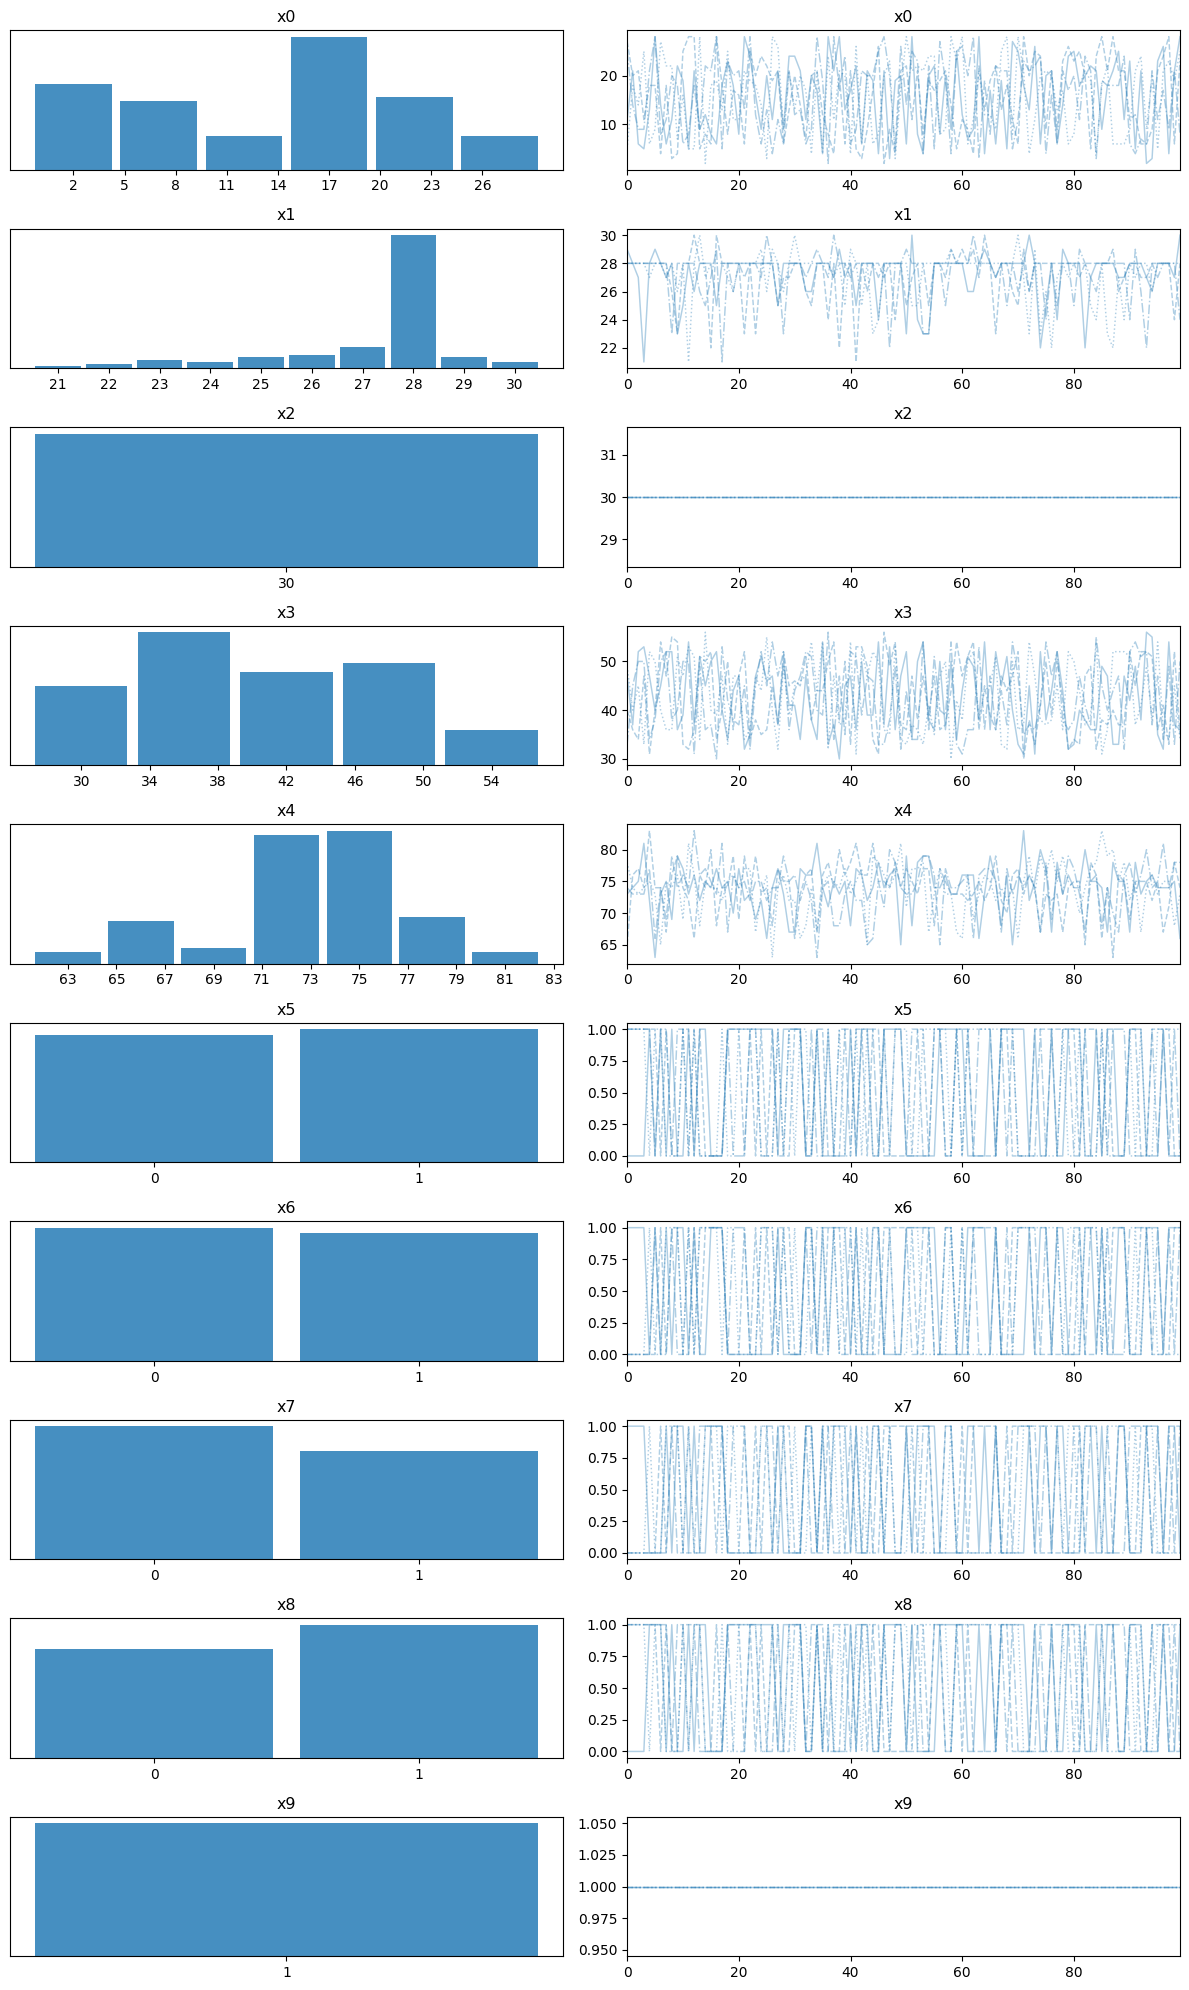

In [23]:
# Trace plot
az.plot_trace(trace);
plt.savefig('unigen_trace_plot.png', dpi=15);

In [14]:
# Diagnosis
az.summary(trace)

/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,15.88,7.775,4.0,28.0,0.347,0.163,487.0,400.0,1.00
x1,27.23,1.751,22.0,29.0,0.086,0.098,496.0,376.0,1.00
x2,30.00,0.000,30.0,30.0,0.000,NaN,400.0,400.0,NaN
x3,42.93,7.419,32.0,54.0,0.332,0.138,490.0,340.0,0.99
x4,73.96,3.914,65.0,80.0,0.194,0.123,342.0,362.0,1.00
x5,0.51,0.501,0.0,1.0,0.026,0.001,368.0,368.0,0.99
x6,0.49,0.501,0.0,1.0,0.026,0.001,368.0,368.0,0.99
x7,0.45,0.498,0.0,1.0,0.027,0.003,339.0,339.0,0.99
x8,0.55,0.498,0.0,1.0,0.027,0.003,339.0,339.0,0.99
x9,1.00,0.000,1.0,1.0,0.000,NaN,400.0,400.0,NaN


In [15]:
utils.save_trace(trace, f'db_cacm_SAT_inc_pyunigen_{num_vars}_{num_bits}.nc')

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) ANALYTICAL SOLUTION
# ============================================================

# list all ages with required median and average age
avg_sat = [
    (x0, x1, 30, x3, x4)
    for x0 in range(31)
    for x1 in range(31)
    for x3 in range(30, 126)
    for x4 in range(30, 126)
    if x0 + x1 + 30 + x3 + x4 == 38 * 5
    and x0 <= x1 <= 30 <= x3 <= x4
]

# list all genders with exactly 3 males
g_sat = [
    (g0, g1, g2, g3, g4)
    for g0 in range(2)
    for g1 in range(2)
    for g2 in range(2)
    for g3 in range(2)
    for g4 in range(2)
    if g0 + g1 + g2 + g3 + g4 == 3
]

# keep only entries with the required average for males
sat_models = [
    ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4))
    for (x0, x1, x2, x3, x4) in avg_sat
    for (g0, g1, g2, g3, g4) in g_sat
    if x0 * g0 + x1 * g1 + x2 * g2 + x3 * g3 + x4 * g4 == 44 * 3
]

# prior on each variable type
p_x01 = lambda x: 1 / 31
p_x2 = lambda x: 1
p_x34 = lambda x: 1 / 96
p_g = lambda x: 1 / 2

# compute unnormalized posterior probabilities
unnormalized_probs = np.array([
    p_x01(x0) * p_x01(x1) * p_x2(x2) * p_x34(x3) * p_x34(x4)
    * p_g(g0) * p_g(g1) * p_g(g2) * p_g(g3) * p_g(g4)
    for ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)) in sat_models
])

# compute total probability mass (normalizing factor)
total_prob = unnormalized_probs.sum()

# normalized probabilities
normalized_probs = unnormalized_probs / total_prob

# put everything in a dataframe
d = {
    'x0': [], 'x1': [], 'x2': [], 'x3': [], 'x4': [],
    'g0': [], 'g1': [], 'g2': [], 'g3': [], 'g4': [],
    'p': []
}

for (((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)), p) in zip(sat_models, normalized_probs):
    d['x0'].append(x0)
    d['x1'].append(x1)
    d['x2'].append(x2)
    d['x3'].append(x3)
    d['x4'].append(x4)
    d['g0'].append(g0)
    d['g1'].append(g1)
    d['g2'].append(g2)
    d['g3'].append(g3)
    d['g4'].append(g4)
    d['p'].append(p)

df = pd.DataFrame(d)

# exact analytical marginal probability
def p_var(var_name, outcome):
    return df.loc[df[var_name] == outcome, 'p'].sum()

# ============================================================
# 2) SINGLE TRACE VS ANALYTICAL SOLUTION
# ============================================================
# Assumes:
#   - `trace` is one ArviZ InferenceData object
#   - trace.posterior contains x0, x1, ..., x9
#
# Mapping:
#   x0..x4  -> exact vars x0..x4
#   x5..x9  -> exact vars g0..g4

def p_est_single(trace, var_name, outcome):
    vals = trace.posterior[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

for x in variables:
    # support of each variable
    if x in ['x0', 'x1']:
        outcomes = range(31)
    elif x == 'x2':
        outcomes = range(30, 31)
    elif x in ['x3', 'x4']:
        outcomes = range(30, 126)
    else:
        outcomes = range(2)

    # map sampled variable name to analytical variable name
    x_conv = x if x in ['x0', 'x1', 'x2', 'x3', 'x4'] else 'g' + str(int(x[1]) - 5)

    # mean absolute difference over the full support
    err = np.mean([
        abs(p_est_single(trace, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err)

df_single_trace = pd.DataFrame(data_single_trace)


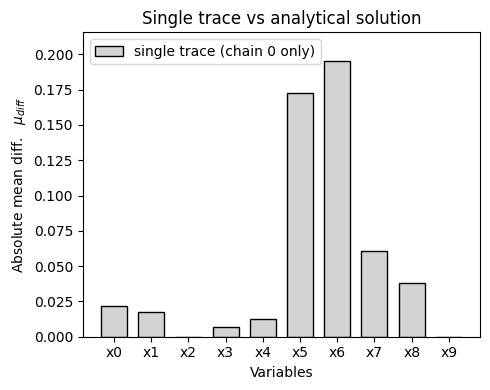

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# empirical probability from ONE CHAIN ONLY (to match your paper code)
def p_est_single_chain(trace, var_name, outcome):
    vals = trace.posterior.sel(chain=0)[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

for x in variables:
    if x in ['x0', 'x1']:
        outcomes = range(31)
    elif x == 'x2':
        outcomes = range(30, 31)
    elif x in ['x3', 'x4']:
        outcomes = range(30, 126)
    else:
        outcomes = range(2)

    x_conv = x if x in ['x0', 'x1', 'x2', 'x3', 'x4'] else 'g' + str(int(x[1]) - 5)

    err = np.mean([
        abs(p_est_single_chain(trace, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err)

df_single_trace = pd.DataFrame(data_single_trace)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

xpos = np.arange(len(df_single_trace))
ax.bar(
    xpos,
    df_single_trace['err_mean_mean'].values,
    color='lightgray',
    edgecolor='black',
    width=0.7,
    label='single trace (chain 0 only)'
)

ax.set_xticks(xpos, df_single_trace['var_name'].values, rotation=0)
ax.set_xlabel('Variables')
ax.set_ylabel(r'Absolute mean diff.   $\mu_{diff}$')
ax.set_title('Single trace vs analytical solution')
ax.legend(loc='upper left')
ax.set_ylim(0, df_single_trace['err_mean_mean'].max() + 0.02)

plt.tight_layout()
plt.show()

  var_name  err_mean_mean
0       x0       0.021864
1       x1       0.017329
2       x2       0.000000
3       x3       0.006994
4       x4       0.012255
5       x5       0.172440
6       x6       0.195573
7       x7       0.061041
8       x8       0.037907
9       x9       0.000000


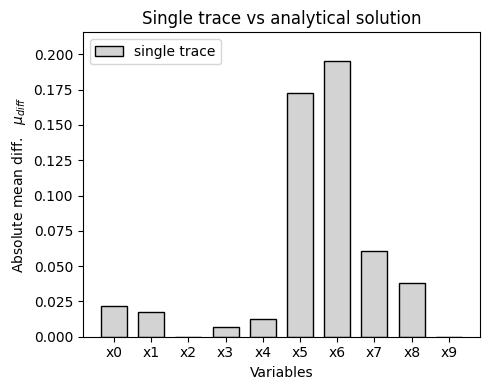

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def p_est_original_style(trace_chain0, var_name, outcome):
    return np.mean(trace_chain0[var_name] == outcome).item()

variables = ['x0','x1','x2','x3','x4','x5','x6','x7','x8','x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

trace_chain0 = trace.posterior.sel(chain=0)

for x in variables:
    ran = range(30, 31)
    if x in ['x0', 'x1']:
        ran = range(31)
    elif x in ['x3', 'x4']:
        ran = range(30, 126)
    elif x in ['x5', 'x6', 'x7', 'x8', 'x9']:
        ran = range(2)

    outcomes = ran
    x_conv = x if x in ['x0','x1','x2','x3','x4'] else 'g' + str(int(x[1]) - 5)

    err_outcome_mean = np.mean([
        np.abs(p_est_original_style(trace_chain0, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err_outcome_mean)

df_single_trace = pd.DataFrame(data_single_trace)
print(df_single_trace)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.bar(
    df_single_trace['var_name'],
    df_single_trace['err_mean_mean'],
    color='lightgray',
    edgecolor='black',
    width=0.7,
    label='single trace'
)
ax.set_xlabel('Variables')
ax.set_ylabel(r'Absolute mean diff.   $\mu_{diff}$')
ax.set_title('Single trace vs analytical solution')
ax.legend(loc='upper left')
ax.set_ylim(0, df_single_trace['err_mean_mean'].max() + 0.02)
plt.tight_layout()
plt.show()